In [3]:
import pandas as pd
from destinations import extract_places


places, dup_places, places_id, dup_places_id = extract_places("Timeline_15_03_26.json")



df_places = pd.DataFrame(places)
df_dup_places = pd.DataFrame(dup_places)
df_dup_places_id = pd.DataFrame(dup_places_id, columns=['places_id'])

print(df_places.head())
print(df_dup_places.head())
print(df_dup_places_id.head())

         lat        lng
0  12.999994  77.550504
1  13.000327  77.549709
2  12.978407  77.579539
3   8.482778  76.943591
4  12.902936  77.521434
         lat        lng
0  12.999994  77.550504
1  13.000327  77.549709
2  12.978407  77.579539
3   8.482778  76.943591
4  12.902936  77.521434
                     places_id
0  ChIJAZBMy5o9rjsRs7xReWDFbGk
1  ChIJecUIuJo9rjsRCPx6gSQcYWM
2  ChIJe628BBIWrjsRm6xlH0hs-xw
3  ChIJNR3otwm7BTsR9x46IbftLx0
4  ChIJlcRpoqY_rjsRaYM90tLmIkw


In [3]:
print("unique places:")
print(df_places.count())

print("duplicate places:")
print(df_dup_places.count())

unique places:
lat    2947
lng    2947
dtype: int64
duplicate places:
lat    15607
lng    15607
dtype: int64


In [4]:
print(df_dup_places.groupby(['lat', 'lng']).size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10))

            lat        lng  counts
876   12.932170  77.522945    1018
2120  52.461768  13.517560     852
817   12.929816  77.520746     589
2795  52.543159  13.412808     501
816   12.929809  77.520738     490
2012  52.451751  13.380756     481
2029  52.455127  13.509395     467
675   12.928054  77.522417     395
1550  13.129463  77.587659     366
724   12.928221  77.522018     293


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'ChIJUcGXEnA_rjsRMrSox30tbw4'),
  Text(1, 0, 'ChIJG1Yzz1A-rjsRAAAAAAAAAAA'),
  Text(2, 0, 'ChIJw0eB0blIqEcRKQ2bh2KN8I8'),
  Text(3, 0, 'ChIJ2bTOy1A-rjsRAAAAAAAAAAA'),
  Text(4, 0, 'ChIJQWh5QVc-rjsRAAAAAAAAAAA'),
  Text(5, 0, 'ChIJlfQ54lk-rjsRp71A7OxmysY'),
  Text(6, 0, 'ChIJT3iQ4Vk-rjsR46F7dYHZu2w'),
  Text(7, 0, 'ChIJA79Q1a9IqEcRPDZBFUCgcrU'),
  Text(8, 0, 'ChIJ51e-Y1FFqEcRtoJtLan9_CY'),
  Text(9, 0, 'ChIJHRQvzwFSqEcR67NNEkdTjtM')])

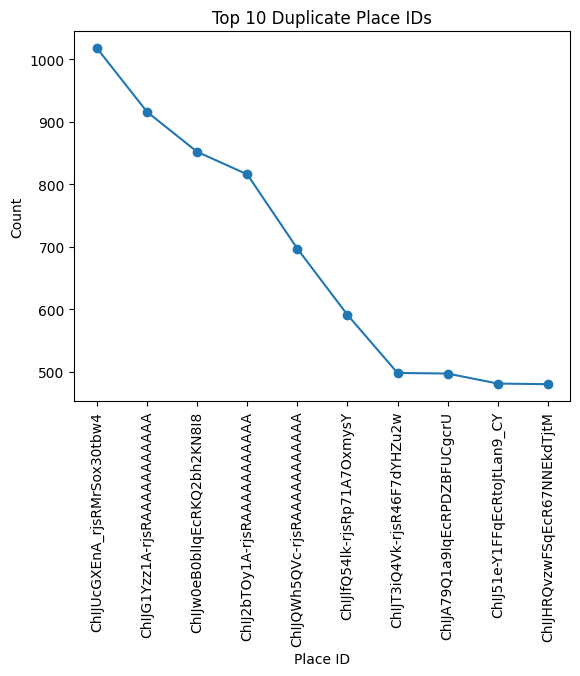

In [6]:
import matplotlib.pyplot as plt

df_dup_places_id_plot = df_dup_places_id.groupby(['places_id']).size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)

plt.plot(df_dup_places_id_plot['places_id'], df_dup_places_id_plot['counts'], marker='o')
plt.title('Top 10 Duplicate Place IDs')
plt.xlabel('Place ID')
plt.ylabel('Count')
plt.xticks(rotation=90)